In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import unicodedata
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, initializers
from sklearn.metrics import (
    classification_report, precision_recall_curve,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)


In [2]:
# =========================================================
# 0. TEXT CLEANING (fixes UnicodeDecodeError: byte 0xc2 ...)
# =========================================================
def clean_text(s):
    """
    Python-side cleaning applied BEFORE data reaches TensorFlow.

    Root cause of the original error: scraped comment data contains
    characters such as the non-breaking space (\\xa0), ©, £, ¢ etc. These are
    encoded in UTF-8 as a two-byte sequence starting with 0xC2. Keras'
    default TextVectorization standardization ('lower_and_strip_punctuation')
    operates at the byte level and can split that two-byte sequence, leaving a
    dangling 0xC2 lead byte that fails to decode ->
    "UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc2 ... unexpected end of data".

    We normalize and strip non-ASCII so no multi-byte sequence survives into
    the byte-level standardizer.
    """
    if not isinstance(s, str):
        s = str(s)
    # Normalize compatibility forms (e.g. smart quotes, full-width chars)
    s = unicodedata.normalize("NFKC", s)
    # Drop any non-ASCII bytes (this removes the 0xC2-class characters)
    s = s.encode("ascii", "ignore").decode("ascii")
    # Collapse whitespace
    s = " ".join(s.split())
    return s if s else "missing_text"


def tf_standardize(input_data):
    """
    Custom standardization run INSIDE the TextVectorization layer.

    Acts as a second line of defense: lowercases, removes any remaining
    non-ASCII bytes, strips punctuation, and collapses whitespace - all on
    well-formed strings so the layer never produces a broken byte sequence.
    """
    lowercase = tf.strings.lower(input_data)
    ascii_only = tf.strings.regex_replace(lowercase, r"[^\x00-\x7F]+", " ")
    no_punct = tf.strings.regex_replace(ascii_only, r"[^a-z0-9\s]", " ")
    return tf.strings.regex_replace(no_punct, r"\s+", " ")


In [3]:
# %%
# =========================================================
# 1. MODELING PIPELINE (Keras Native)
# =========================================================
def build_bilstm_pipeline(train_texts, num_classes, initial_bias=None, max_tokens=20000, output_sequence_length=150):
    """
    Constructs an end-to-end Keras model that handles raw text.
    """
    # 1. Text Vectorization Layer
    vectorize_layer = layers.TextVectorization(
        max_tokens=max_tokens,
        output_mode='int',
        output_sequence_length=output_sequence_length,
        standardize=tf_standardize 
    )
    vectorize_layer.adapt(train_texts)
    
    # 2. Set up the output bias array for imbalanced multi-label data
    if initial_bias is not None:
        output_bias = initializers.Constant(initial_bias)
    else:
        output_bias = 'zeros'

    # 3. Model Architecture
    inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
    x = vectorize_layer(inputs)
    x = layers.Embedding(input_dim=max_tokens, output_dim=128)(x) 
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    # OUTPUT CHANGE: num_classes nodes, sigmoid remains for independent probabilities
    outputs = layers.Dense(num_classes, activation='sigmoid', bias_initializer=output_bias)(x)

    model = Model(inputs=inputs, outputs=outputs)
    
    # METRIC CHANGE: multi_label flag enabled for correct AUC calculation
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.BinaryFocalCrossentropy(),
        metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True, num_labels=num_classes)]
    )
    
    return model



In [4]:
# %%
# =========================================================
# 2. EVALUATION FUNCTIONS (Untouched)
# =========================================================
def plot_threshold_curves(y_true, y_probs, class_name, dataset_name="Validation"):
    """Plots Precision, Recall, and F1 across all thresholds 0-1."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)
    
    f1_scores = np.divide(
        2 * (precision * recall), 
        (precision + recall), 
        out=np.zeros_like(precision), 
        where=(precision + recall) != 0
    )
    
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    
    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, precision[:-1], label='Precision', color='#1f77b4', linestyle='--')
    plt.plot(thresholds, recall[:-1], label='Recall', color='#ff7f0e', linestyle='-.')
    plt.plot(thresholds, f1_scores[:-1], label='F1 Score', color='#2ca02c', linewidth=2.5)
    plt.axvline(best_threshold, color='red', linestyle=':', label=f'Best Threshold: {best_threshold:.2f}')
    
    # TITLE CHANGE: Added class_name
    plt.title(f'[{class_name}] {dataset_name}: Metrics vs. Classification Threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend(loc='lower left')
    plt.grid(alpha=0.3)
    plt.show()
    
    return best_threshold

def plot_dual_confusion_matrix(y_val, y_val_probs, y_test, y_test_probs, class_name, threshold=0.5):
    """Side-by-side CM for Validation and Test datasets using a custom threshold."""
    y_val_pred = (y_val_probs >= threshold).astype(int)
    y_test_pred = (y_test_probs >= threshold).astype(int)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    cm_val = confusion_matrix(y_val, y_val_pred)
    ConfusionMatrixDisplay(cm_val, display_labels=["Non-Toxic", "Toxic"]).plot(ax=axes[0], cmap='Blues', colorbar=False)
    # TITLE CHANGE: Added class_name
    axes[0].set_title(f"[{class_name}] Val CM (Thresh={threshold:.2f})")
    
    cm_test = confusion_matrix(y_test, y_test_pred)
    ConfusionMatrixDisplay(cm_test, display_labels=["Non-Toxic", "Toxic"]).plot(ax=axes[1], cmap='Greens', colorbar=False)
    # TITLE CHANGE: Added class_name
    axes[1].set_title(f"[{class_name}] Test CM (Thresh={threshold:.2f})")
    
    plt.tight_layout()
    plt.show()



In [5]:
def create_threshold_metrics_table(y_true, y_probs, step=0.05):
    """
    Generates a table of TP, FP, TN, FN across thresholds from 0 to 1.
    """
    thresholds = np.arange(0.0, 1.0 + step, step)
    results = []
    
    for t in thresholds:
        # Convert probabilities to hard labels based on current threshold t
        preds = (y_probs >= t).astype(int)
        
        # labels=[0,1] ensures it always returns a 2x2 matrix, even if preds are all 0 or all 1
        cm = confusion_matrix(y_true, preds, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        
        results.append({
            "Threshold": f"{t:.2f}",
            "TP": tp,
            "FP": fp,
            "TN": tn,
            "FN": fn
        })
        
    df_metrics = pd.DataFrame(results)
    return df_metrics




Loading data...

🚀 [STAGE 1] Initializing Multi-Label Pipeline...
🚀 Training Multi-Label Bi-LSTM...
Epoch 1/30
4999/4999 [==============================] - 200s 39ms/step - loss: 0.0176 - auc: 0.8816 - val_loss: 0.0133 - val_auc: 0.9683
Epoch 2/30
4999/4999 [==============================] - 196s 39ms/step - loss: 0.0137 - auc: 0.9534 - val_loss: 0.0137 - val_auc: 0.9726
Epoch 3/30
4999/4999 [==============================] - 197s 39ms/step - loss: 0.0126 - auc: 0.9660 - val_loss: 0.0127 - val_auc: 0.9728
Epoch 4/30
4999/4999 [==============================] - 198s 40ms/step - loss: 0.0118 - auc: 0.9731 - val_loss: 0.0124 - val_auc: 0.9733
Epoch 5/30
4999/4999 [==============================] - 198s 40ms/step - loss: 0.0109 - auc: 0.9787 - val_loss: 0.0124 - val_auc: 0.9696
Epoch 6/30
4999/4999 [==============================] - 198s 40ms/step - loss: 0.0101 - auc: 0.9825 - val_loss: 0.0127 - val_auc: 0.9680
Epoch 7/30
4999/4999 [==============================] - 199s 40ms/step - loss:

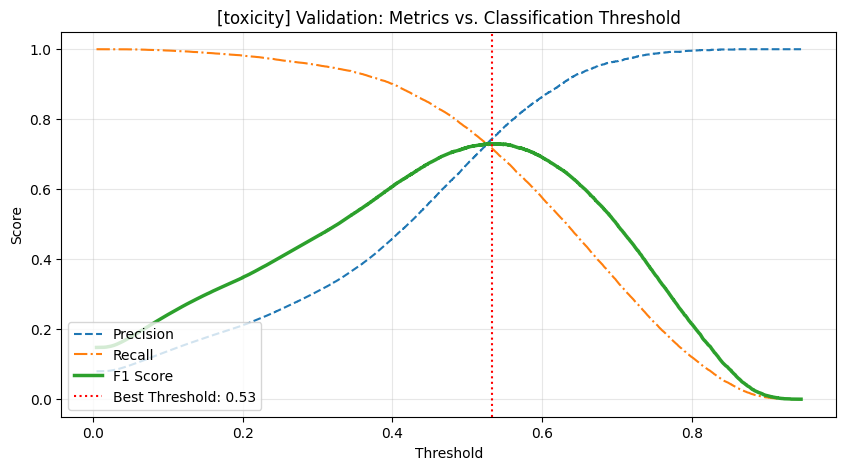


✅ Optimal Threshold for toxicity based on F1: 0.53


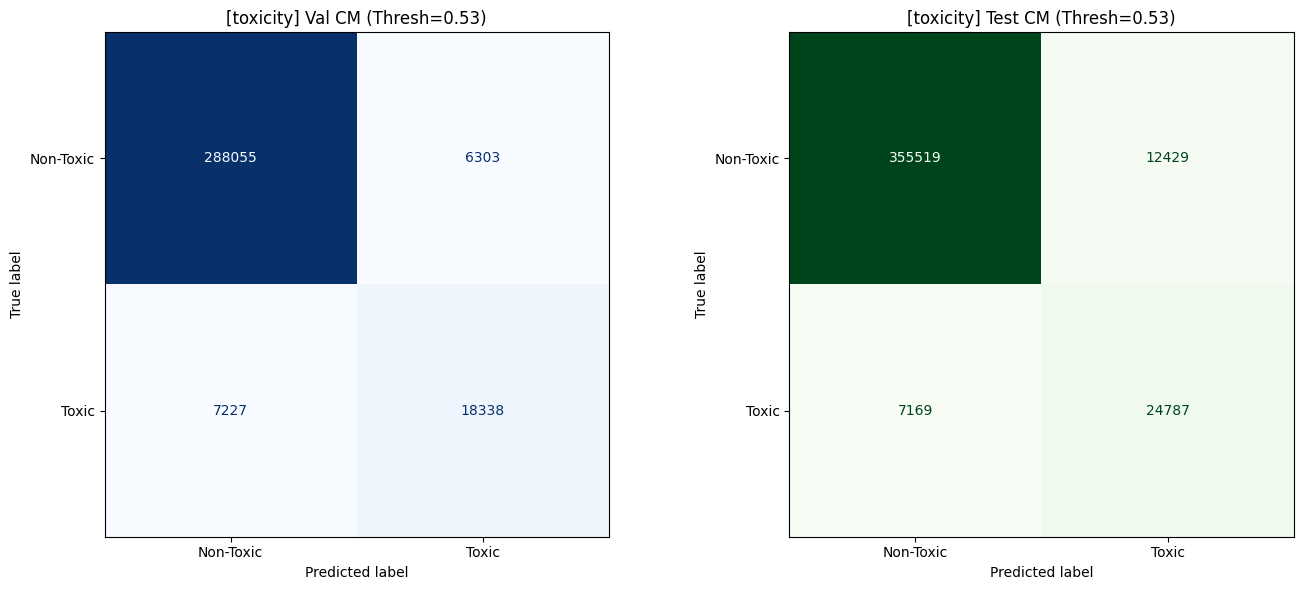


🔍 ANALYZING CLASS: OBSCENE

Validation Threshold Metrics for obscene:
Threshold   TP     FP     TN   FN
     0.00 2192 317731      0    0
     0.05 2178 151796 165935   14
     0.10 2040  29495 288236  152
     0.15 1942   7311 310420  250
     0.20 1872   4021 313710  320
     0.25 1775   2622 315109  417
     0.30 1643   1778 315953  549
     0.35 1457   1185 316546  735
     0.40 1242    703 317028  950
     0.45  998    418 317313 1194
     0.50  758    228 317503 1434
     0.55  555    112 317619 1637
     0.60  372     47 317684 1820
     0.65  232     12 317719 1960
     0.70  116      2 317729 2076
     0.75   55      1 317730 2137
     0.80   25      0 317731 2167
     0.85    7      0 317731 2185
     0.90    2      0 317731 2190
     0.95    0      0 317731 2192
     1.00    0      0 317731 2192


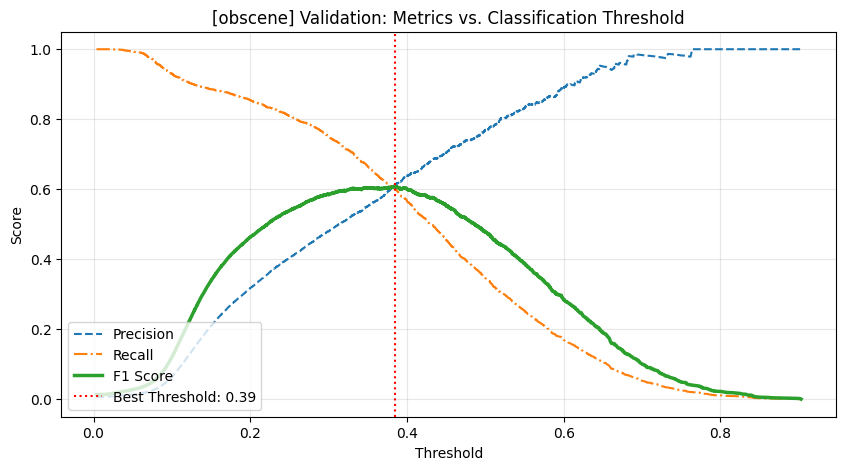


✅ Optimal Threshold for obscene based on F1: 0.39


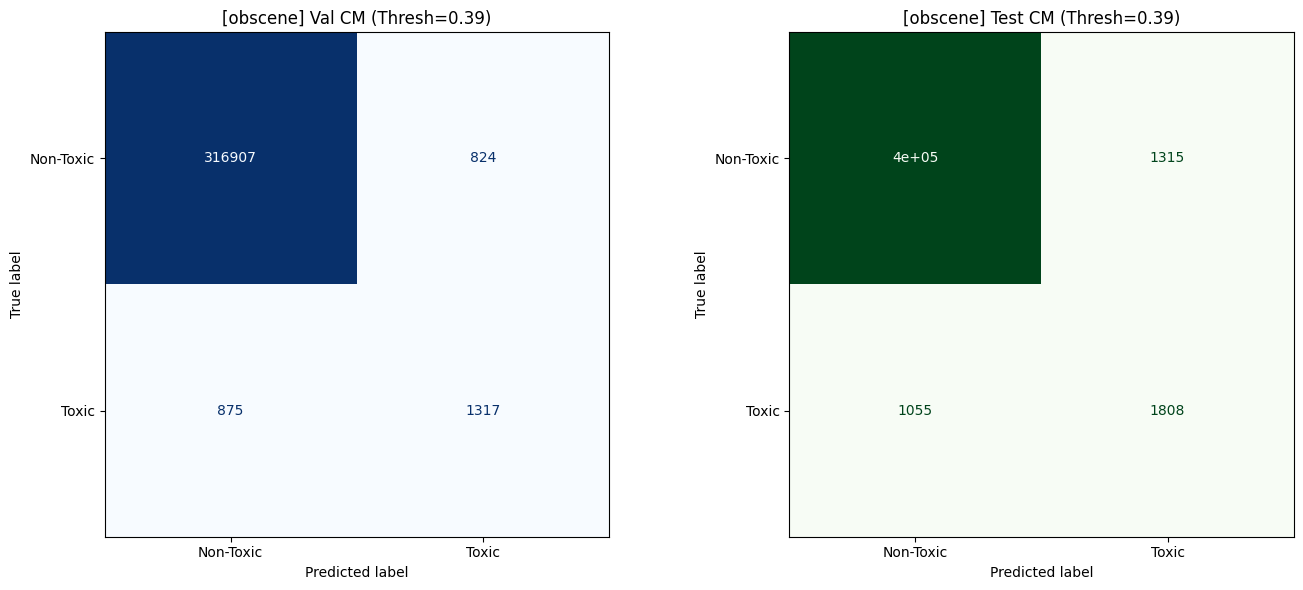


🔍 ANALYZING CLASS: SEXUAL_EXPLICIT

Validation Threshold Metrics for sexual_explicit:
Threshold  TP     FP     TN  FN
     0.00 831 319092      0   0
     0.05 800  65122 253970  31
     0.10 740   9427 309665  91
     0.15 687   4416 314676 144
     0.20 620   2597 316495 211
     0.25 557   1600 317492 274
     0.30 489    945 318147 342
     0.35 391    560 318532 440
     0.40 309    310 318782 522
     0.45 237    169 318923 594
     0.50 177     84 319008 654
     0.55 124     40 319052 707
     0.60  84     19 319073 747
     0.65  53     10 319082 778
     0.70  26      3 319089 805
     0.75  10      1 319091 821
     0.80   3      1 319091 828
     0.85   1      0 319092 830
     0.90   1      0 319092 830
     0.95   0      0 319092 831
     1.00   0      0 319092 831


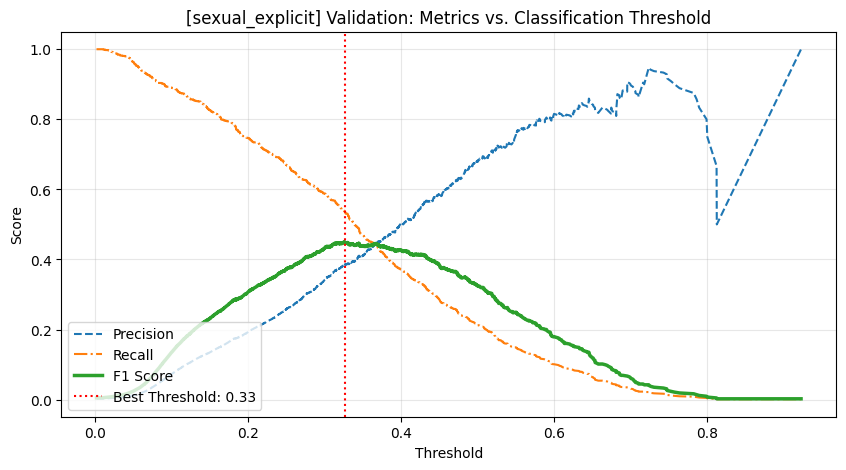


✅ Optimal Threshold for sexual_explicit based on F1: 0.33


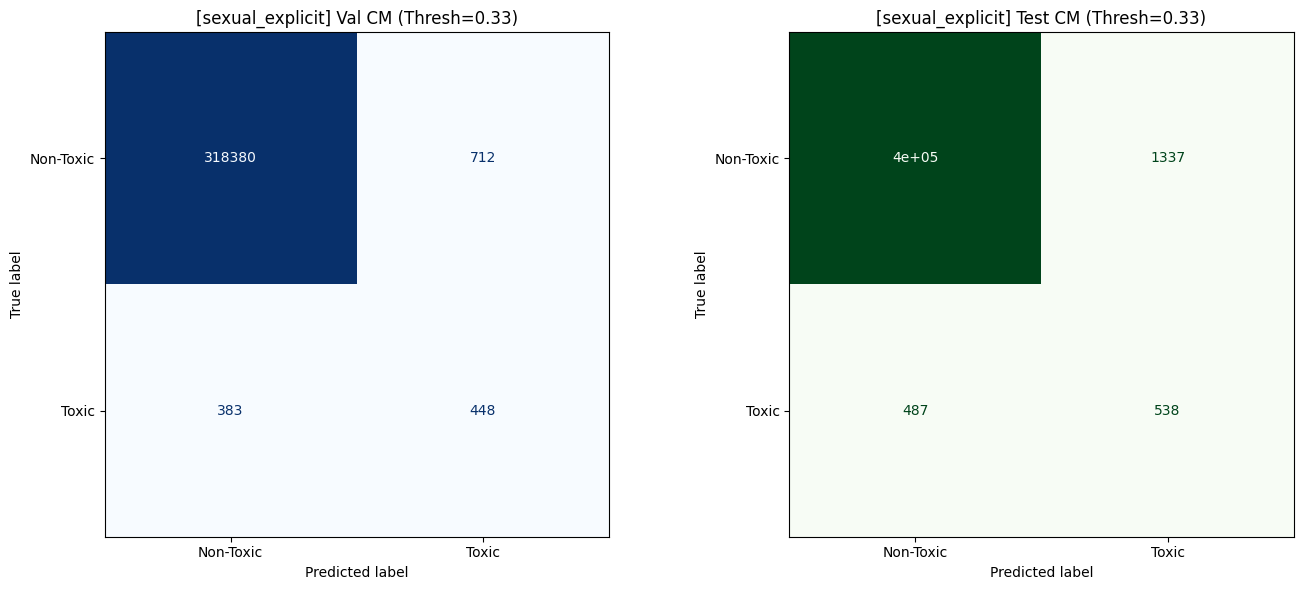


🔍 ANALYZING CLASS: IDENTITY_ATTACK

Validation Threshold Metrics for identity_attack:
Threshold   TP     FP     TN   FN
     0.00 1743 318180      0    0
     0.05 1729 125419 192761   14
     0.10 1673  46524 271656   70
     0.15 1615  25566 292614  128
     0.20 1574  17372 300808  169
     0.25 1498  12185 305995  245
     0.30 1380   8296 309884  363
     0.35 1234   5274 312906  509
     0.40 1020   3135 315045  723
     0.45  765   1590 316590  978
     0.50  504    683 317497 1239
     0.55  286    247 317933 1457
     0.60  114     59 318121 1629
     0.65   35     13 318167 1708
     0.70    6      1 318179 1737
     0.75    1      0 318180 1742
     0.80    0      0 318180 1743
     0.85    0      0 318180 1743
     0.90    0      0 318180 1743
     0.95    0      0 318180 1743
     1.00    0      0 318180 1743


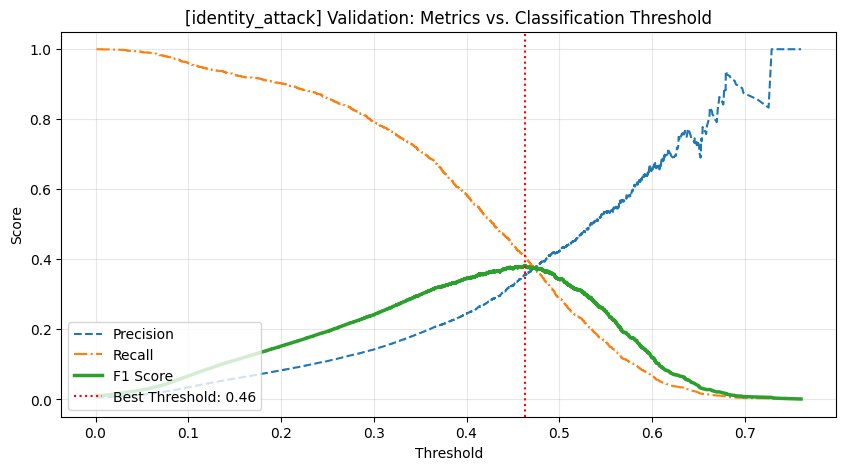


✅ Optimal Threshold for identity_attack based on F1: 0.46


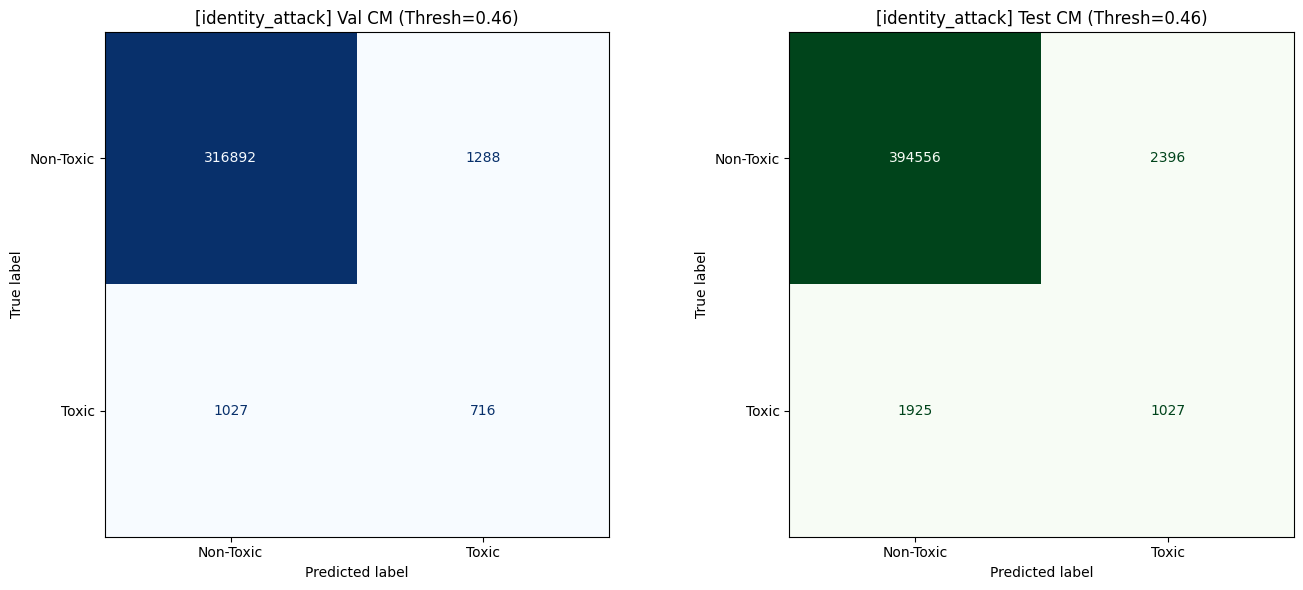


🔍 ANALYZING CLASS: INSULT

Validation Threshold Metrics for insult:
Threshold    TP     FP     TN    FN
     0.00 20873 299050      0     0
     0.05 20857 202866  96184    16
     0.10 20780 136079 162971    93
     0.15 20657 100440 198610   216
     0.20 20456  73298 225752   417
     0.25 20212  52293 246757   661
     0.30 19849  37014 262036  1024
     0.35 19353  25541 273509  1520
     0.40 18549  16409 282641  2324
     0.45 17309   9555 289495  3564
     0.50 15627   5069 293981  5246
     0.55 13411   2333 296717  7462
     0.60 10781    913 298137 10092
     0.65  7866    302 298748 13007
     0.70  5063     75 298975 15810
     0.75  2707     13 299037 18166
     0.80  1033      0 299050 19840
     0.85   175      0 299050 20698
     0.90     3      0 299050 20870
     0.95     0      0 299050 20873
     1.00     0      0 299050 20873


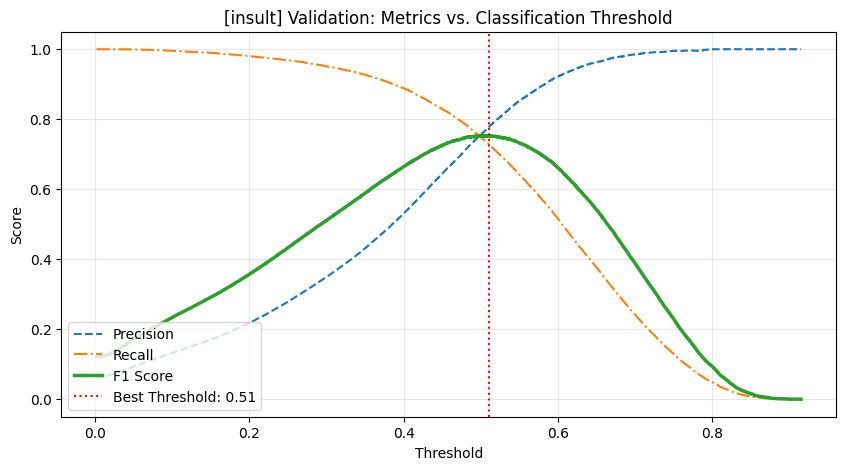


✅ Optimal Threshold for insult based on F1: 0.51


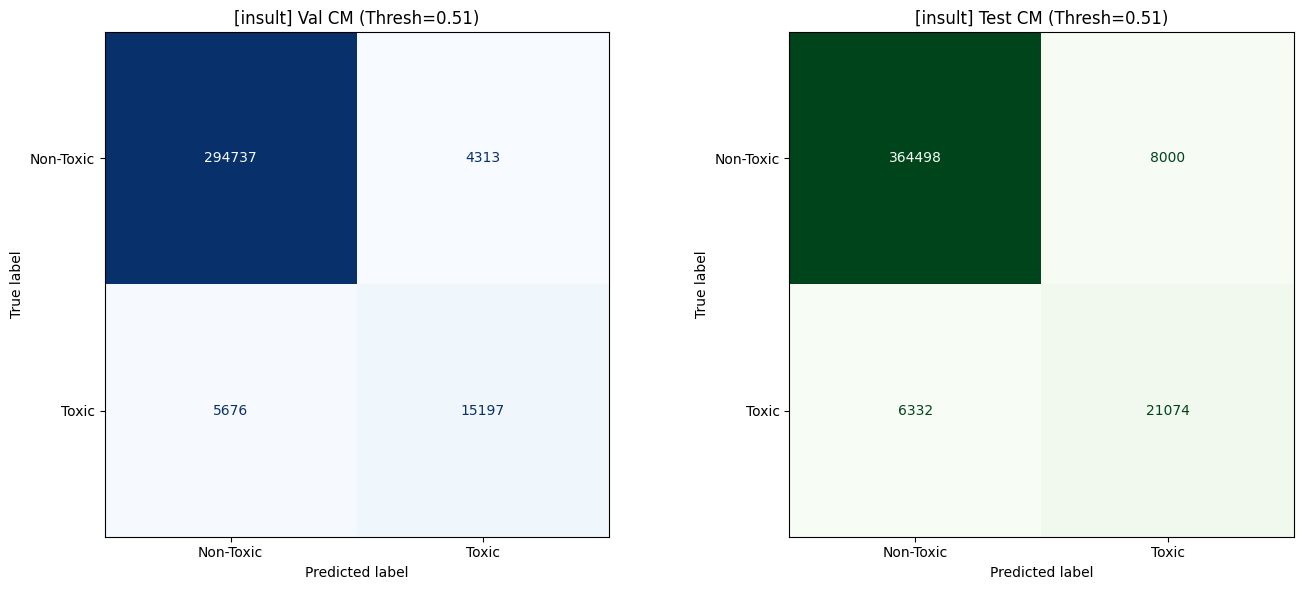


🔍 ANALYZING CLASS: THREAT

Validation Threshold Metrics for threat:
Threshold  TP     FP     TN  FN
     0.00 756 319167      0   0
     0.05 730  61664 257503  26
     0.10 630  11012 308155 126
     0.15 543   4356 314811 213
     0.20 468   2219 316948 288
     0.25 396   1270 317897 360
     0.30 328    708 318459 428
     0.35 271    393 318774 485
     0.40 219    225 318942 537
     0.45 165    137 319030 591
     0.50 118     83 319084 638
     0.55  86     40 319127 670
     0.60  58     20 319147 698
     0.65  38      9 319158 718
     0.70  22      5 319162 734
     0.75   8      4 319163 748
     0.80   3      3 319164 753
     0.85   1      1 319166 755
     0.90   0      0 319167 756
     0.95   0      0 319167 756
     1.00   0      0 319167 756


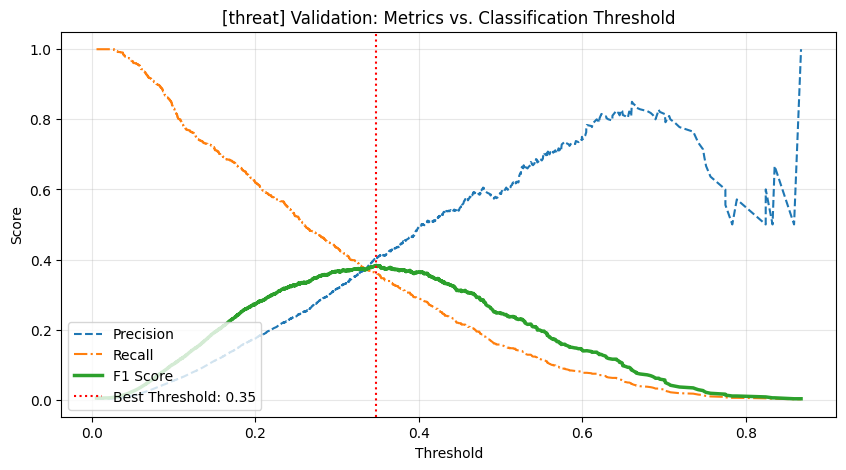


✅ Optimal Threshold for threat based on F1: 0.35


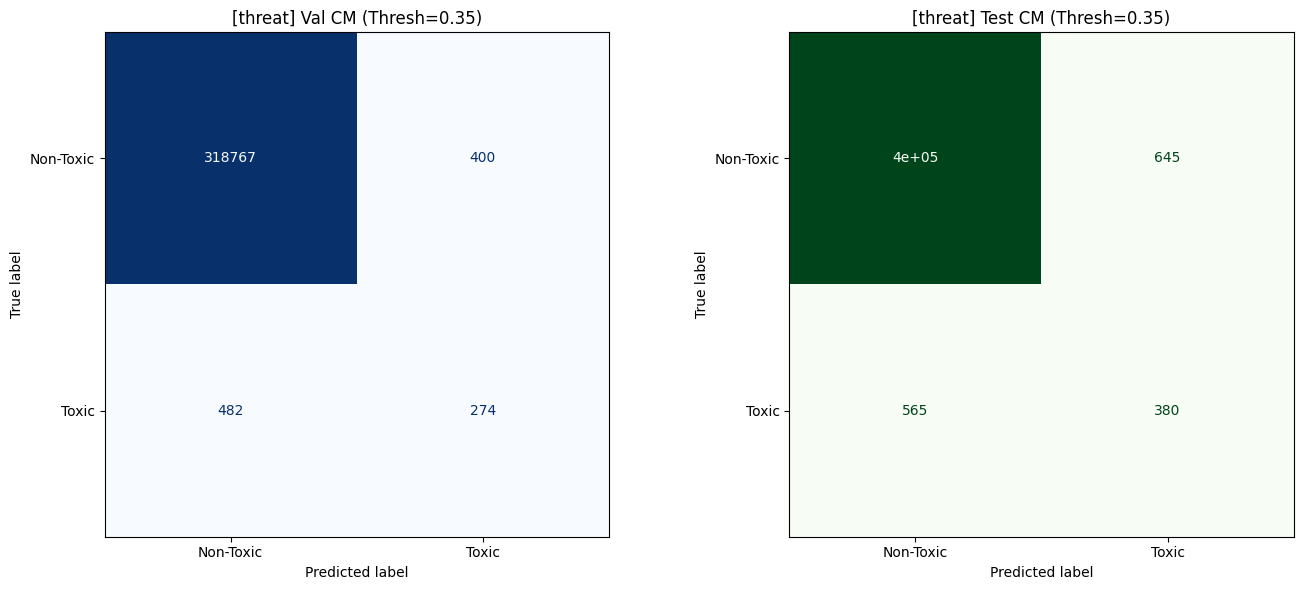


--- Final Optimal Thresholds Dictionary ---
{'toxicity': 0.53300464, 'obscene': 0.38537392, 'sexual_explicit': 0.3263156, 'identity_attack': 0.4630754, 'insult': 0.51102275, 'threat': 0.34822953}


In [6]:
# =========================================================
# 3. MAIN EXECUTION
# =========================================================
if __name__ == "__main__":
    # 1. Configuration
    TEXT_COL = 'comment_text'
    # Define all your labels (Main + Sub-labels)
    TARGET_COLS = ['toxicity', 'obscene', 'sexual_explicit', 'identity_attack', 'insult', 'threat']
    NUM_CLASSES = len(TARGET_COLS)
    
    # 2. Load Data 
    print("Loading data...")
    train_df = pd.read_csv("data/input/train_split.csv").fillna({TEXT_COL: "missing_text"})
    val_df = pd.read_csv("data/input/val_split.csv").fillna({TEXT_COL: "missing_text"})
    test_df = pd.read_csv("data/input/test_split.csv").fillna({TEXT_COL: "missing_text"})

    # Clean text Python-side
    train_df[TEXT_COL] = train_df[TEXT_COL].map(clean_text)
    val_df[TEXT_COL] = val_df[TEXT_COL].map(clean_text)
    test_df[TEXT_COL] = test_df[TEXT_COL].map(clean_text)

    # Build text inputs
    X_train = train_df[TEXT_COL].to_numpy(dtype=object)
    X_val = val_df[TEXT_COL].to_numpy(dtype=object)
    X_test = test_df[TEXT_COL].to_numpy(dtype=object)
    
    # Build 2D target arrays
    Y_train = train_df[TARGET_COLS].to_numpy()
    Y_val = val_df[TARGET_COLS].to_numpy()
    Y_test = test_df[TARGET_COLS].to_numpy()
    
    # ==========================================
    # STAGE 1: TRAIN MULTI-LABEL BASELINE
    # ==========================================
    # Calculate initial bias for EACH class to prevent loss explosion on rare classes
    initial_biases = []
    for col in TARGET_COLS:
        pos = (train_df[col] == 1).sum()
        neg = (train_df[col] == 0).sum()
        bias = np.log((pos + 1e-7) / (neg + 1e-7))
        initial_biases.append(bias)
    initial_biases = np.array(initial_biases)
    
    print("\n🚀 [STAGE 1] Initializing Multi-Label Pipeline...")
    model_v1 = build_bilstm_pipeline(
        train_texts=X_train, 
        num_classes=NUM_CLASSES, 
        initial_bias=initial_biases
    )
    
    early_stopping = callbacks.EarlyStopping(
        monitor='val_auc', verbose=1, patience=5, mode='max', restore_best_weights=True
    )
    
    print("🚀 Training Multi-Label Bi-LSTM...")
    model_v1.fit(
        x=X_train, y=Y_train,
        batch_size=256, epochs=30, callbacks=[early_stopping],
        validation_data=(X_val, Y_val)
        # Note: class_weight is completely removed here. Focal loss handles the 2D imbalance.
    )
    
    # ==========================================
    # STAGE 2: EVALUATE ALL LABELS
    # ==========================================
    print("\n--- Generating Predictions ---")
    val_probs = model_v1.predict(X_val, batch_size=256)
    test_probs = model_v1.predict(X_test, batch_size=256)
    
    optimal_thresholds = {}

    print("\n--- Multi-Label Threshold Analysis ---")
    for i, class_name in enumerate(TARGET_COLS):
        print(f"\n{'='*50}")
        print(f"🔍 ANALYZING CLASS: {class_name.upper()}")
        print(f"{'='*50}")
        
        # Isolate the specific column for this sub-label
        y_val_true_class = Y_val[:, i]
        y_val_probs_class = val_probs[:, i]
        y_test_true_class = Y_test[:, i]
        y_test_probs_class = test_probs[:, i]
        
        # 1. Metrics Table
        val_metrics_table = create_threshold_metrics_table(y_val_true_class, y_val_probs_class, step=0.05)
        print(f"\nValidation Threshold Metrics for {class_name}:")
        print(val_metrics_table.to_string(index=False))
        
        # 2. Threshold Curves
        best_thresh = plot_threshold_curves(y_val_true_class, y_val_probs_class, class_name=class_name, dataset_name="Validation")
        optimal_thresholds[class_name] = best_thresh
        
        print(f"\n✅ Optimal Threshold for {class_name} based on F1: {best_thresh:.2f}")
        
        # 3. Confusion Matrices
        plot_dual_confusion_matrix(
            y_val=y_val_true_class, y_val_probs=y_val_probs_class,
            y_test=y_test_true_class, y_test_probs=y_test_probs_class,
            class_name=class_name, threshold=best_thresh
        )

    print("\n--- Final Optimal Thresholds Dictionary ---")
    print(optimal_thresholds)

In [7]:
# ==========================================
# STAGE 3: SAVE MODEL & ARTIFACTS
# ==========================================
import json
import os

# Ensure the models directory exists
os.makedirs("models", exist_ok=True)

print("\n--- Saving Model and Artifacts ---")

# 1. Save Keras Model (Forcing 'tf' SavedModel directory format)
model_v1.save("models/multilabel_model", save_format="tf")

# 2. Package all dynamically generated thresholds and labels
# We cast np.float32 to standard float so JSON can serialize it
inference_artifacts = {
    "optimal_thresholds": {k: float(v) for k, v in optimal_thresholds.items()},
    "target_cols": TARGET_COLS
}

# 3. Save as JSON
with open("models/multilabel_inference_artifacts.json", "w") as f:
    json.dump(inference_artifacts, f, indent=4)
    
print("✅ Successfully saved the model and thresholds to the 'models/' directory.")


--- Saving Model and Artifacts ---


INFO:tensorflow:Assets written to: models/multilabel_model\assets


INFO:tensorflow:Assets written to: models/multilabel_model\assets


✅ Successfully saved the model and thresholds to the 'models/' directory.
